In [5]:
## Custom CNN for Image Based AQI Prediction


In [1]:
%pip install tensorflow

  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl (351.2 MB)
Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32
DATA_DIR = "./static/" 

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2, # Splits 20% of data for testing/validation
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True
)

train_generator = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    classes=['good', 'moderate', 'unhealthy', 'Unhealthy for Sensitive Groups'] # Forces exact mapping
)

validation_generator = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    classes=['good', 'moderate', 'unhealthy', 'Unhealthy for Sensitive Groups']
)

print("Class Indices:", train_generator.class_indices)

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax') # 4 outputs for 4 classes
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS = 15 
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS
)

# model.save('aqi_classifier_model.keras')
# print("Model saved successfully as 'aqi_classifier_model.keras'")

Found 4783 images belonging to 4 classes.
Found 1194 images belonging to 4 classes.
Class Indices: {'good': 0, 'moderate': 1, 'unhealthy': 2, 'Unhealthy for Sensitive Groups': 3}
Epoch 1/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 228s 1s/step - accuracy: 0.5382 - loss: 0.9834 - val_accuracy: 0.5235 - val_loss: 1.5191
Epoch 2/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.6621 - loss: 0.7575 - val_accuracy: 0.5042 - val_loss: 2.1511
Epoch 3/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 150s 999ms/step - accuracy: 0.7002 - loss: 0.6710 - val_accuracy: 0.5410 - val_loss: 1.5380
Epoch 4/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 137s 915ms/step - accuracy: 0.7292 - loss: 0.6128 - val_accuracy: 0.5092 - val_loss: 2.1209
Epoch 5/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 142s 946ms/step - accuracy: 0.7581 - loss: 0.5440 - val_accuracy: 0.5126 - val_loss: 3.3326
Epoch 6/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 115s 763ms/step - accuracy: 0.7901 - loss: 0.4969 - val_accuracy: 0.5268 - val_loss: 3.8727
Epoch 7/15
150/150 ━━━━━━━━━━━━━━━━

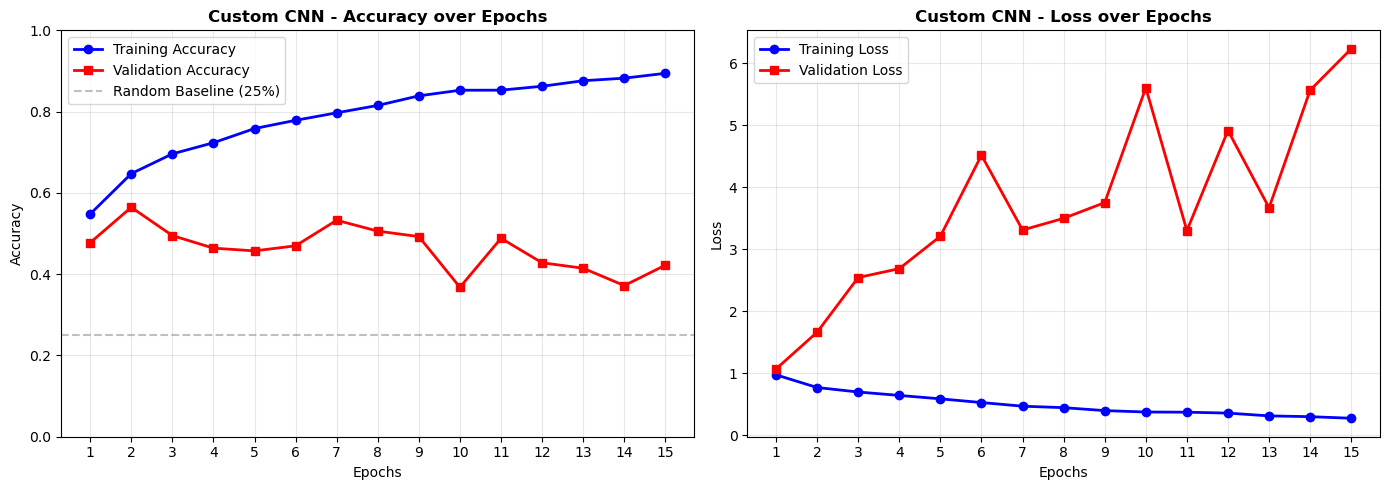

In [6]:
import matplotlib.pyplot as plt

epochs = list(range(1, 16))
accuracy = [0.5478, 0.6473, 0.6960, 0.7234, 0.7583, 0.7786, 0.7970, 0.8152, 0.8388, 0.8526, 0.8528, 0.8624, 0.8760, 0.8823, 0.8942]
val_accuracy = [0.4774, 0.5645, 0.4950, 0.4640, 0.4573, 0.4698, 0.5327, 0.5059, 0.4925, 0.3677, 0.4883, 0.4280, 0.4146, 0.3719, 0.4221]
loss = [0.9722, 0.7676, 0.6950, 0.6400, 0.5849, 0.5252, 0.4662, 0.4427, 0.3951, 0.3724, 0.3694, 0.3548, 0.3099, 0.2971, 0.2717]
val_loss = [1.0670, 1.6602, 2.5424, 2.6856, 3.2085, 4.5159, 3.3087, 3.4975, 3.7512, 5.6037, 3.2992, 4.9144, 3.6676, 5.5646, 6.2327]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(epochs, accuracy, 'b-o', label='Training Accuracy', linewidth=2, markersize=6)
ax1.plot(epochs, val_accuracy, 'r-s', label='Validation Accuracy', linewidth=2, markersize=6)
ax1.axhline(y=0.25, color='gray', linestyle='--', alpha=0.5, label='Random Baseline (25%)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.set_title('Custom CNN - Accuracy over Epochs', fontweight='bold')
ax1.legend()
ax1.set_ylim(0, 1.0)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(epochs)

# Loss plot
ax2.plot(epochs, loss, 'b-o', label='Training Loss', linewidth=2, markersize=6)
ax2.plot(epochs, val_loss, 'r-s', label='Validation Loss', linewidth=2, markersize=6)
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.set_title('Custom CNN - Loss over Epochs', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(epochs)

plt.tight_layout()
# plt.savefig('Custom CNN Training Accuracy and Loss over Epochs')
plt.show()



Found 1718 images belonging to 4 classes.
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 161ms/step


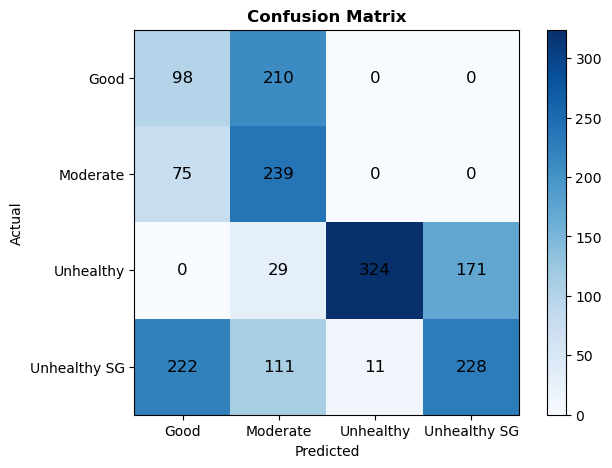

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

model = tf.keras.models.load_model('airvision/models/aqi_classifier_model.keras')

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
val_gen = datagen.flow_from_directory('static/', target_size=(150, 150), batch_size=32,
    class_mode='categorical', subset='validation',
    classes=['good', 'moderate', 'unh', 'Unhealthy for Sensitive Groups'], shuffle=False)

val_gen.reset()
steps = int(np.ceil(val_gen.samples / 32))
preds = model.predict(val_gen, steps=steps)
pred_classes = np.argmax(preds, axis=1)
true_classes = val_gen.classes

cm = confusion_matrix(true_classes, pred_classes)
labels = ['Good', 'Moderate', 'Unhealthy', 'Unhealthy SG']

plt.figure(figsize=(7, 5))
plt.imshow(cm, cmap='Blues')
for i in range(4):
    for j in range(4):
        plt.text(j, i, int(cm[i][j]), ha='center', va='center', fontsize=12)
plt.xticks(range(4), labels)
plt.yticks(range(4), labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix', fontweight='bold')
plt.colorbar()
# plt.savefig(' Confusion matrix of Custom CNN')
plt.show()